# iFood Marketing Analytics Project

## Objectives
1. Data Exploration
2. Customer Segmentation
3. Classification Modeling
4. Business Recommendations

Goal:
Use customer data to identify marketing opportunities and improve campaign effectiveness.

Business Problem:
How can iFood improve campaign effectiveness through customer segmentation and predictive analytics?

Unit of Analysis:
Each observation represents an individual customer.

Data Dimensions:
Cross-sectional customer-level marketing dataset including demographics, spending behavior, and campaign responses.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/ifood_df.csv')

df.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [3]:
df.shape

(2205, 39)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Income                2205 non-null   float64
 1   Kidhome               2205 non-null   int64  
 2   Teenhome              2205 non-null   int64  
 3   Recency               2205 non-null   int64  
 4   MntWines              2205 non-null   int64  
 5   MntFruits             2205 non-null   int64  
 6   MntMeatProducts       2205 non-null   int64  
 7   MntFishProducts       2205 non-null   int64  
 8   MntSweetProducts      2205 non-null   int64  
 9   MntGoldProds          2205 non-null   int64  
 10  NumDealsPurchases     2205 non-null   int64  
 11  NumWebPurchases       2205 non-null   int64  
 12  NumCatalogPurchases   2205 non-null   int64  
 13  NumStorePurchases     2205 non-null   int64  
 14  NumWebVisitsMonth     2205 non-null   int64  
 15  AcceptedCmp3         

In [5]:
df.describe()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,...,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.000000,2205.00000
mean,51622.094785,0.442177,0.506576,49.009070,306.164626,26.403175,165.312018,37.756463,27.128345,44.057143,...,0.257596,0.034467,0.089796,0.024490,0.504762,0.165079,0.215873,562.764626,518.707483,0.29932
std,20713.063826,0.537132,0.544380,28.932111,337.493839,39.784484,217.784507,54.824635,41.130468,51.736211,...,0.437410,0.182467,0.285954,0.154599,0.500091,0.371336,0.411520,575.936911,553.847248,0.68044
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.00000
25%,35196.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.000000,42.000000,0.00000
50%,51287.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.00000
75%,68281.000000,1.000000,1.000000,74.000000,507.000000,33.000000,232.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,884.000000,0.00000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.00000


In [6]:
df.isnull().sum()

,0
Income,0
Kidhome,0
Teenhome,0
Recency,0
MntWines,0
MntFruits,0
MntMeatProducts,0
MntFishProducts,0
MntSweetProducts,0
MntGoldProds,0


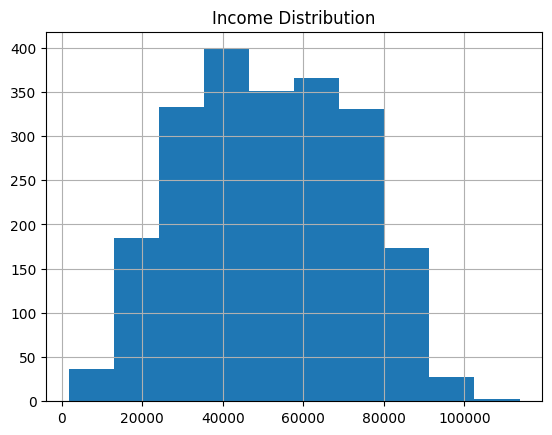

In [7]:
import matplotlib.pyplot as plt

df['Income'].hist()
plt.title('Income Distribution')
plt.show()

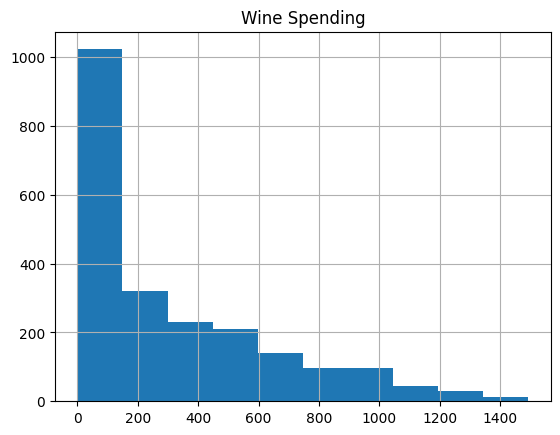

In [8]:
df['MntWines'].hist()
plt.title('Wine Spending')
plt.show()

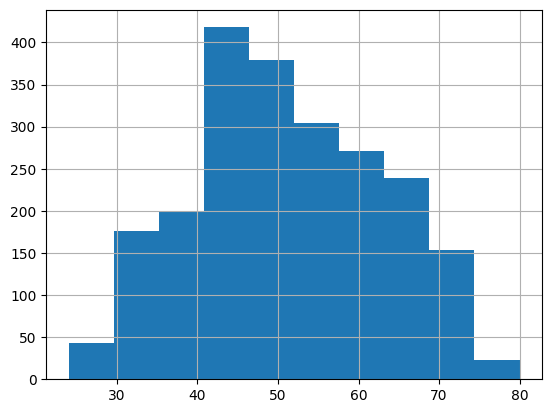

In [10]:
df['Age'].hist()
plt.show()

In [11]:
from sklearn.cluster import KMeans

X = df[['Income','MntWines','MntMeatProducts']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Segment'] = kmeans.fit_predict(X)

df[['Income','Segment']].groupby('Segment').mean()

,Income
Segment,
0,75599.553521
1,28239.643052
2,51804.386334


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df[['Income','Recency','MntWines']]
y = df['Response']

X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.3,random_state=42)

model=RandomForestClassifier()
model.fit(X_train,y_train)

pred=model.predict(X_test)

print(accuracy_score(y_test,pred))

0.8549848942598187


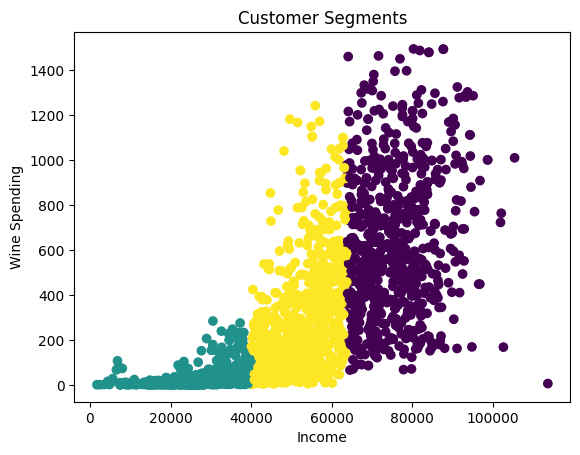

In [14]:
import matplotlib.pyplot as plt

plt.scatter(df['Income'], df['MntWines'], c=df['Segment'])
plt.xlabel('Income')
plt.ylabel('Wine Spending')
plt.title('Customer Segments')
plt.show()

In [13]:
import pandas as pd

importance = pd.DataFrame({
'Feature': X.columns,
'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

    Feature  Importance
0    Income    0.379154
2  MntWines    0.347923
1   Recency    0.272924


In [15]:
import pandas as pd

fi = pd.DataFrame({
'Feature':X.columns,
'Importance':model.feature_importances_
}).sort_values(by='Importance',ascending=False)

print(fi)

    Feature  Importance
0    Income    0.379154
2  MntWines    0.347923
1   Recency    0.272924


In [16]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test,pred))
print(classification_report(y_test,pred))

[[539  32]
 [ 64  27]]
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       571
           1       0.46      0.30      0.36        91

    accuracy                           0.85       662
   macro avg       0.68      0.62      0.64       662
weighted avg       0.83      0.85      0.84       662



Key Insights:
• Higher-income customers spend more on premium products.
• Customer segments show distinct spending behaviors.
• Response to campaigns can be predicted using customer attributes.

Key Findings
• Higher-value customers show stronger spending patterns.
• Segmentation reveals distinct customer groups for targeted campaigns.
• Classification modeling suggests customer response can be predicted using behavioral variables.

Recommendations:
• Target high-value segments with premium campaigns
• Use promotions for price-sensitive customers
• Focus marketing on customers most likely to respond
• Improve retention strategies for low-engagement customers

Reflection on Using AI:
• AI helped clarify business objectives before coding.
• AI supported step-by-step model development.
• I used AI to learn analytical methods rather than simply generate answers.